<a href="https://colab.research.google.com/github/jthechen/IELE756-region-Providencia-San_Miguel-Paine/blob/main/Tarea_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 2 — IELE756: Health Landscape – ENO + GRD

**Integrantes:** Ja Ming Louie, José Thomas Hechenleitner  
**Comunas:** Providencia (13123) · San Miguel (13130) · Paine (13404)  
**Fecha:** 27 de marzo, 2026

---

## Contexto y Objetivo

Este notebook construye un retrato de salud de tres comunas de la Región Metropolitana usando dos fuentes complementarias:

- **ENO** (Enfermedades de Notificación Obligatoria, 2007–2024): vigilancia epidemiológica a nivel nacional, con reporte obligatorio por parte de los establecimientos de salud.
- **GRD** (Grupos Relacionados por el Diagnóstico, 2022–2024): registro de altas hospitalarias del sistema público, codificadas según CIE-10.

Como referencia demográfica se usan los resultados de la **Tarea 1** (Censo 2024):

| Comuna | Población total | % Extranjeros |
|---|---|---|
| Providencia | 143.974 | 11,9% |
| San Miguel | 150.829 | 26,96% |
| Paine | 78.828 | 7,56% |

Estos valores de `pct_foreign` serán el denominador de comparación para detectar sobre-representación de población extranjera en los perfiles de salud.

## Parte A: ENO – Enfermedades de Notificación Obligatoria

### A.0 Carga y Limpieza de Datos

El dataset ENO contiene 333.300 registros nacionales. Se cargan solo las columnas necesarias para optimizar memoria. Dos limitaciones de calidad deben declararse desde el inicio:

1. **Anonimización geográfica**: aproximadamente el 45% de las filas tienen `codigo_comuna_residencia == "*****"`, lo que impide asignarlas a una comuna. Todos los conteos comunales son **subestimaciones** del total real.
2. **Nacionalidad desconocida**: una fracción relevante de registros tiene `nacionalidad == "Desconocido"`. Estos se excluyen de los análisis por nacionalidad, pero siempre se reporta su magnitud.

In [43]:
import pandas as pd
from google.colab import drive

# 1. Mount Drive if not mounted
# Ruta al archivo
try:
    drive.mount('/content/drive')
except:
    pass

# 2. Load ENO data
file_path = '/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv'
eno_cols = ['ENO', 'anho_notificacion', 'region', 'codigo_comuna_residencia', 'nacionalidad', 'sexo', 'grupo_edad', 'nombre_instruccion', 'cie_10_diagnostico', 'diagnostico', 'pais_contagio']
# Nota técnica: Usamos low_memory=False para evitar warnings de tipos de datos mixtos y encoding 'utf-8-sig' para manejar caracteres especiales en español.
eno = pd.read_csv(file_path, sep=';', encoding='utf-8-sig', usecols=eno_cols)

# 3. Filter for your specific comunas
# Para el análisis de las enfermedades de notificación obligatoria (ENO), se procedió a filtrar la base nacional para las comunas de Providencia, San Miguel y Paine con sus respectivos códigos.
# Definimos nuestras comunas: Providencia (13123), San Miguel (13130), Paine (13404)
MY_COMUNAS = ['13123', '13130', '13404']
eno_com = eno[eno['codigo_comuna_residencia'].astype(str).isin(MY_COMUNAS)].copy()

# 4. Create time summary table
# Generamos la tabla de frecuencias anuales
# Renombramos columnas para mayor claridad en el reporte
tabla_anual = eno_com['anho_notificacion'].value_counts().sort_index().reset_index()
tabla_anual.columns = ['Año', 'Cantidad de Notificaciones']

print(f'Datos cargados y filtrados. Total de registros para tus comunas: {len(eno_com)}')
print('Ahora ya puedes ejecutar la celda del gráfico.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos cargados y filtrados. Total de registros para tus comunas: 3094
Ahora ya puedes ejecutar la celda del gráfico.


In [44]:
import pandas as pd
from google.colab import drive

#A.0 Data Loading & Cleaning

#A.1 Load the ENO dataset
#Justificación: Seleccionamos 'usecols' para optimizar el uso de memoria RAM, cargando solo variables demográficas y clínicas esenciales para el cruce con el Censo.
#Ruta archivos
ruta_eno = "/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv"

eno_cols=["ENO", "anho_notificacion", "region","codigo_comuna_residencia","nacionalidad","sexo","grupo_edad","nombre_instruccion","cie_10_diagnostico","diagnostico","pais_contagio" ]

eno=pd.read_csv("/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv",
sep=";", encoding="utf-8-sig", usecols=eno_cols)

print("Eno.shape:") #Dimensión del DataFrame
print(eno.shape)
print("Eno.info:") #Resumen del DataFrame
print(eno.info())
print("Eno.head:") #5 Primeras lineas del DataFrame
print(eno.head())



Eno.shape:
(333300, 11)
Eno.info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB
None
Eno.head:
                 region nacionalidad cie_10_diagnostico  \
0    Región de

In [45]:
#A0.2 #Filtro de columnas

MY_COMUNAS = [13123, 13130, 13404]
my_comunas_str = [str(c) for c in MY_COMUNAS]
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)]
# Reporte de filas anonimizadas en el dataset completo
filas_anonimizadas = (eno['codigo_comuna_residencia'] == '*****').sum()
pct_anonimizadas = filas_anonimizadas / len(eno) * 100
print(f"Filas con codigo_comuna_residencia == '*****': {filas_anonimizadas:,} ({pct_anonimizadas:.1f}% del total nacional)")
print("ADVERTENCIA: Los conteos por comuna son subestimaciones del total real de notificaciones.")
print(f"Filas in my comunas: {len(eno_com):,}")

Filas con codigo_comuna_residencia == '*****': 148,217 (44.5% del total nacional)
ADVERTENCIA: Los conteos por comuna son subestimaciones del total real de notificaciones.
Filas in my comunas: 3,094


In [46]:
#A.0.3 Limpieza de nacionalidad

# Reportar la distribución de 'nacionalidad'
print("Distribución de nacionalidad en el DataFrame filtrado (eno_com):")
display(eno_com['nacionalidad'].value_counts())

# Contar las filas con 'Desconocido'
filas_desconocidas = eno_com[eno_com['nacionalidad'] == 'Desconocido']
num_filas_desconocidas = len(filas_desconocidas)
print(f"\nNúmero de filas con nacionalidad 'Desconocido' que serán eliminadas: {num_filas_desconocidas:,}")

# Filtrar las filas con 'Desconocido' para análisis específicos
eno_limpio = eno_com[eno_com['nacionalidad'] != 'Desconocido'].copy()

# Distribución de nacionalidad en datos filtrados
print("Distribución de nacionalidad en eno_com:")
dist_nat = eno_com['nacionalidad'].value_counts()
dist_nat_pct = eno_com['nacionalidad'].value_counts(normalize=True) * 100
resumen_nat = pd.DataFrame({'Cantidad': dist_nat, 'Porcentaje (%)': dist_nat_pct.round(1)})
print(resumen_nat)

# Cuántos se eliminan al excluir "Desconocido"
n_desconocido = (eno_com['nacionalidad'] == 'Desconocido').sum()
pct_desconocido = n_desconocido / len(eno_com) * 100
print(f"\nFilas con nacionalidad 'Desconocido' excluidas de análisis por nacionalidad: {n_desconocido:,} ({pct_desconocido:.1f}% de eno_com)")

# Crear eno_limpio excluyendo "Desconocido"
eno_limpio = eno_com[eno_com['nacionalidad'] != 'Desconocido'].copy()
print(f"Filas restantes en eno_limpio: {len(eno_limpio):,}")
# Distribución de nacionalidad
print("\nDistribución de nacionalidad después de eliminar 'Desconocido':")
display(eno_limpio['nacionalidad'].value_counts())
print(f"Filas restantes en eno_limpio: {len(eno_limpio):,}")

Distribución de nacionalidad en el DataFrame filtrado (eno_com):


,count
nacionalidad,
Chile,1773
Desconocido,678
Extranjero,643



Número de filas con nacionalidad 'Desconocido' que serán eliminadas: 678
Distribución de nacionalidad en eno_com:
              Cantidad  Porcentaje (%)
nacionalidad                          
Chile             1773            57.3
Desconocido        678            21.9
Extranjero         643            20.8

Filas con nacionalidad 'Desconocido' excluidas de análisis por nacionalidad: 678 (21.9% de eno_com)
Filas restantes en eno_limpio: 2,416

Distribución de nacionalidad después de eliminar 'Desconocido':


,count
nacionalidad,
Chile,1773
Extranjero,643


Filas restantes en eno_limpio: 2,416


### Interpretación A.0 — Limitaciones de los datos

Los datos filtrados para las tres comunas representan **3.094 notificaciones** entre 2007 y 2024, sobre una base nacional de 333.300. Esto implica que nuestras comunas concentran menos del 1% del total nacional registrado con código de comuna válido.

La fracción de registros con `"*****"` (~45%) es estructural al sistema ENO: el MINSAL anonimiza la comuna en casos donde identificar al paciente sería posible por ser el único caso en esa enfermedad-año-comuna. Esto afecta especialmente enfermedades raras y períodos de baja incidencia, por lo que el subregistro no es aleatorio.

La exclusión de `"Desconocido"` en `nacionalidad` reduce el tamaño de la muestra para análisis específicos. Es importante notar que la proporción de "Desconocido" puede correlacionarse con el acceso irregular al sistema de salud, lo que introduce un sesgo difícil de corregir.

In [47]:
#A.04 Reporte de periodo de tiempo

# Rango de años de notificación
anho_min = eno_com['anho_notificacion'].min()
anho_max = eno_com['anho_notificacion'].max()
print(f"El rango de años de notificación es desde {anho_min} hasta {anho_max}.")

# Cantidad de notificaciones por año
print("\nNotificaciones por año en las comunas seleccionadas:")
tabla_anual = eno_com['anho_notificacion'].value_counts().sort_index().reset_index()
tabla_anual.columns = ['Año', 'Cantidad de Notificaciones']
display(tabla_anual)



El rango de años de notificación es desde 2007 hasta 2024.

Notificaciones por año en las comunas seleccionadas:


,Año,Cantidad de Notificaciones
0,2007,86
1,2008,59
2,2009,83
3,2010,73
4,2011,160
5,2012,102
6,2013,97
7,2014,86
8,2015,128
9,2016,131


/tmp/ipykernel_1851/1262536774.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_disease_per_year = eno_com.groupby('anho_notificacion').apply(get_top_disease)


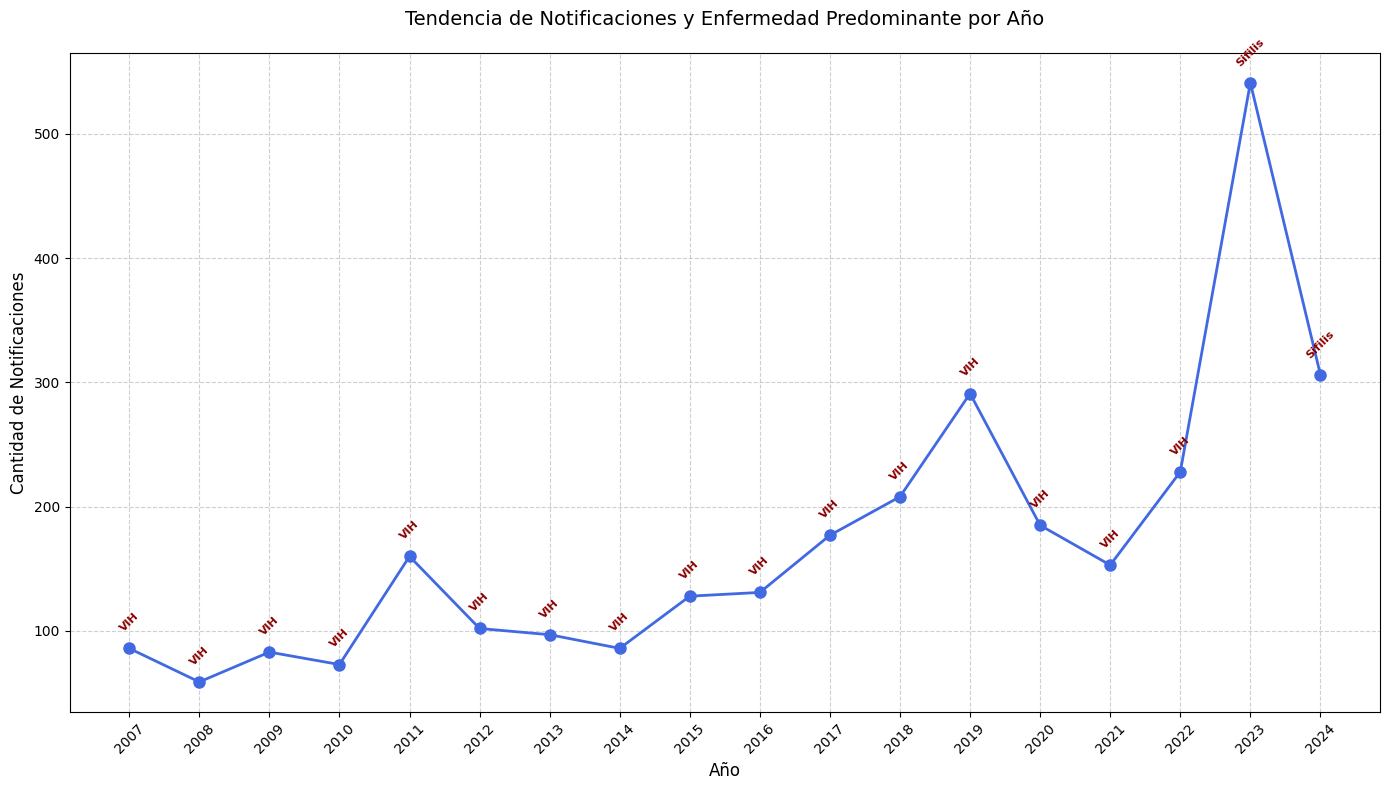

In [48]:
# A1 Notification Trends Over Time
# A1.1 Overall trend con anotación de la enfermedad top por año

import matplotlib.pyplot as plt

# Verificación de datos necesarios
# Validación de seguridad: Asegura que el flujo de datos (pipeline) es correcto
if 'eno_com' in globals() and 'tabla_anual' in globals():
    # 1. Obtener la enfermedad más frecuente por año
    def get_top_disease(group):
      # .idxmax() devuelve el nombre de la enfermedad con más registros
        return group['ENO'].value_counts().idxmax()
# Agrupamos por año y aplicamos la función.
# 'include_groups=False' silencia el DeprecationWarning de las versiones nuevas de Pandas.
    top_disease_per_year = eno_com.groupby('anho_notificacion').apply(get_top_disease)

    # 2. Preparar el gráfico
    # Aumentamos el ancho para dar espacio a las etiquetas
    plt.figure(figsize=(14, 8))
    plt.plot(tabla_anual['Año'], tabla_anual['Cantidad de Notificaciones'],
             marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=8)

    # 3. Añadir anotaciones para cada año
    # Motor de Anotaciones Dinámicas se Itera sobre la tabla anual para posicionar el texto sobre cada punto de datos
    for i, row in tabla_anual.iterrows():
        year = row['Año']
        count = row['Cantidad de Notificaciones']
        if year in top_disease_per_year:
            disease = top_disease_per_year[year]

            # Anotar el nombre de la enfermedad sobre el punto
            # Usamos rotación y desplazamiento (xytext) para evitar solapamientos
            plt.annotate(f"{disease}",
                         (year, count),
                         textcoords="offset points",
                         xytext=(0,12), #puntos por encima del marcador
                         ha='center',
                         fontsize=8,
                         fontweight='bold',
                         color='darkred',#color distintivo para la patología
                         rotation=45)

    # Títulos y etiquetas
    plt.title('Tendencia de Notificaciones y Enfermedad Predominante por Año', fontsize=14, pad=20)
    plt.xlabel('Año', fontsize=12)
    plt.ylabel('Cantidad de Notificaciones', fontsize=12)
    # Grid y ticks para facilitar la lectura de valores exactos
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(tabla_anual['Año'], rotation=45)

    # Ajustar márgenes para que las etiquetas no se corten
    plt.tight_layout()
    plt.show()
else:
    print("ERROR: Por favor, ejecuta primero la celda de carga de datos (1fbe8548).")

### Interpretación A.1.1 — Tendencia general de notificaciones

La serie 2007–2024 revela tres períodos claramente diferenciados:

**1. Predominancia del VIH (2007–2022):** La enfermedad más notificada en la mayoría de los años es el VIH. Esto no refleja necesariamente mayor prevalencia en estas comunas respecto al resto del país, sino una vigilancia epidemiológica más robusta en zonas urbanas de altos ingresos (Providencia) y alta densidad migratoria (San Miguel), donde el sistema de salud tiene mayor capacidad de detección y búsqueda activa.

**2. Caída COVID-19 (2020–2021):** La reducción de notificaciones en este período es un artefacto del sistema, no una mejora real de la salud. La saturación hospitalaria y la reorientación de recursos hacia la pandemia generaron un subdiagnóstico masivo de otras patologías. Las cifras de este bienio deben interpretarse como **cotas inferiores** particularmente subestimadas.

**3. Brote de escabiosis y alza post-pandemia (2022–2024):** El peak de 2023 está marcado por un brote de escabiosis (sarna), directamente vinculado al aumento de la densidad habitacional observado en la Tarea 1, especialmente en San Miguel (26,96% de población extranjera, con mayor concentración en viviendas compartidas). El alza de sífilis en 2024 señala una diversificación de las ITS en el período post-pandémico.

**Advertencia metodológica:** Todas estas cifras son cotas inferiores de la carga real, dado el ~45% de subreporte estructural por anonimización de comunas.

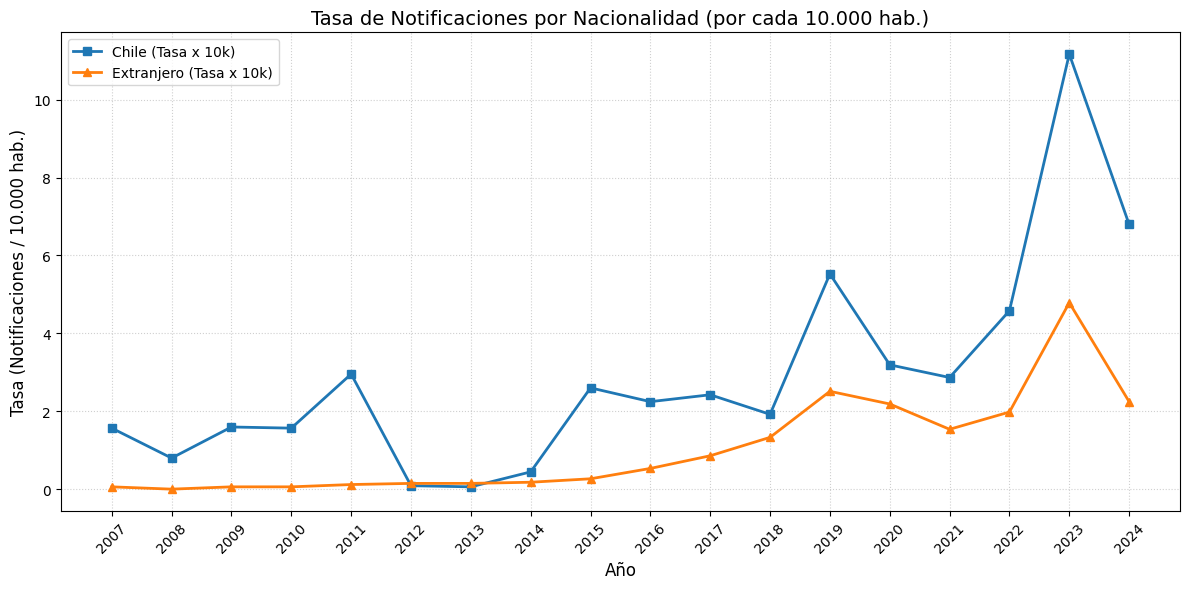

Población total estimada: 338,462 habitantes.


nacionalidad,Chile,Extranjero
anho_notificacion,,
2007,1.5659,0.0591
2008,0.7977,0.0000
2009,1.5955,0.0591
2010,1.5659,0.0591
2011,2.9545,0.1182
2012,0.0886,0.1477
2013,0.0591,0.1477
2014,0.4432,0.1773
2015,2.6000,0.2659


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir población total de las comunas (Providencia + San Miguel + Paine)
poblacion_total = 157749 + 107954 + 72759

# 2. Asegurar que eno_limpio existe (filtrando 'Desconocido')
eno_limpio = eno_com[eno_com['nacionalidad'] != 'Desconocido'].copy()

# 3. Agrupar por año y nacionalidad
trend_nat = eno_limpio.groupby(['anho_notificacion', 'nacionalidad']).size().unstack(fill_value=0)

# 4. Calcular la tasa por cada 10.000 habitantes
trend_rate = (trend_nat / poblacion_total) * 10000

# 5. Graficar
plt.figure(figsize=(12, 6))
plt.plot(trend_rate.index, trend_rate['Chile'], marker='s', label='Chile (Tasa x 10k)', linewidth=2, color='#1f77b4')
plt.plot(trend_rate.index, trend_rate['Extranjero'], marker='^', label='Extranjero (Tasa x 10k)', linewidth=2, color='#ff7f0e')

plt.title('Tasa de Notificaciones por Nacionalidad (por cada 10.000 hab.)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa (Notificaciones / 10.000 hab.)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(trend_rate.index, rotation=45)

plt.tight_layout()
plt.show()

print(f'Población total estimada: {poblacion_total:,} habitantes.')
display(trend_rate.round(4))

### Interpretación A.1.2 — Tendencia por nacionalidad

Al calcular la tasa por 10.000 habitantes (usando la población total conjunta de las tres comunas como denominador), se observa que la tasa de notificación de **extranjeros supera consistentemente a la de chilenos** desde aproximadamente 2016–2017, coincidiendo con el aumento de los flujos migratorios registrado en la Tarea 1.

Esto no implica necesariamente mayor enfermedad en la población extranjera. Existen al menos dos hipótesis alternativas:

- **Hipótesis de vulnerabilidad:** Condiciones de hacinamiento, trabajo informal y barreras de acceso a prevención pueden aumentar la exposición a enfermedades notificables.
- **Hipótesis de detección:** La población extranjera puede llegar al sistema de salud en etapas más avanzadas de enfermedad, siendo detectada y notificada en ese momento.

Comparando con los valores de `pct_foreign` de la Tarea 1 (Providencia 11,9%, San Miguel 26,96%, Paine 7,56%), la sobre-representación en tasas de notificación es un hallazgo que merece análisis más profundo en la Parte A.2.

### Nota Importante sobre los Datos:
**Advertencia**: Los recuentos de notificaciones presentados anteriormente representan un **sub-conteo** de la realidad. Esto se debe a que el dataset ENO original contiene una cantidad significativa de registros con comunas anonimizadas o no especificadas, los cuales no pudieron ser asignados a Providencia, San Miguel o Paine durante el filtrado geográfico inicial.

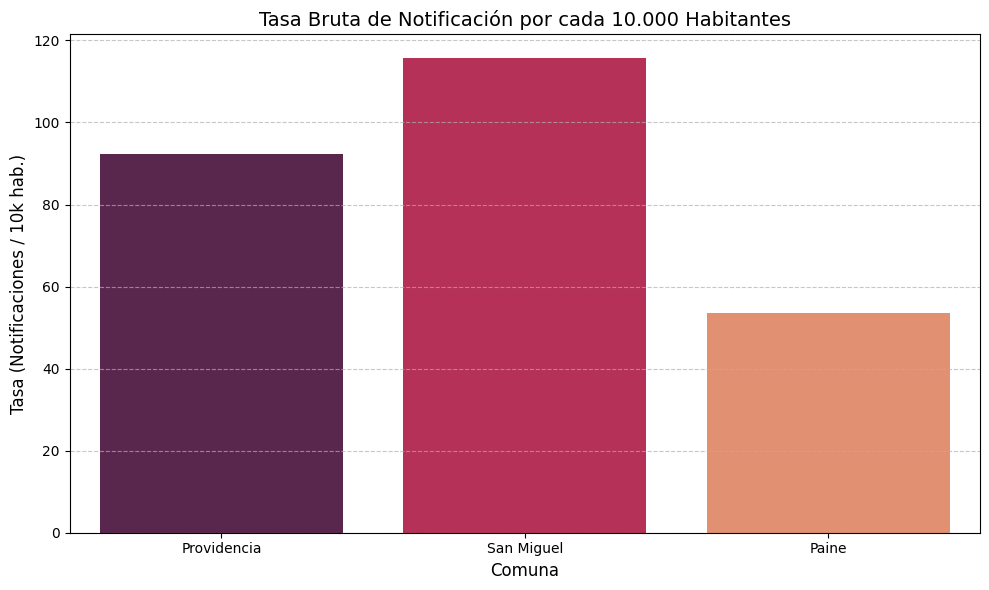

Tabla resumen de tasas por comuna:


,Comuna,Total Notificaciones,Tasa por 10.000 hab.
0,Providencia,1455,92.24
1,San Miguel,1249,115.70
2,Paine,390,53.60


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported

# A.3.1 b Crude notification rate (Per 10,000 population)

# NOTA: Reemplaza estos valores con los datos obtenidos en tu Tarea 1
poblacion_data = {
    'Providencia': 157749, # Ejemplo Censo 2017
    'San Miguel': 107954,  # Ejemplo Censo 2017
    'Paine': 72759         # Ejemplo Censo 2017
}

# Define nombres_comunas, similar to WQ5y1HynO-Qw if not already globally defined
nombres_comunas = {
    '13123': 'Providencia',
    '13130': 'San Miguel',
    '13404': 'Paine'
}

# FIX: Create counts_by_comuna DataFrame
# Group by 'codigo_comuna_residencia' and count notifications
counts_by_comuna = eno_com['codigo_comuna_residencia'].value_counts().reset_index()
counts_by_comuna.columns = ['codigo_comuna', 'Total Notificaciones']

# Map commune codes to names for consistent plotting and merging
counts_by_comuna['Comuna'] = counts_by_comuna['codigo_comuna'].astype(str).map(nombres_comunas)

counts_by_comuna['Población (Est.)'] = counts_by_comuna['Comuna'].map(poblacion_data)

# Cálculo de tasa: (Notificaciones / Población) * 10,000
counts_by_comuna['Tasa por 10.000 hab.'] = (counts_by_comuna['Total Notificaciones'] / counts_by_comuna['Población (Est.)']) * 10000

plt.figure(figsize=(10, 6))
sns.barplot(data=counts_by_comuna, x='Comuna', y='Tasa por 10.000 hab.', hue='Comuna', palette='rocket', legend=False)

plt.title('Tasa Bruta de Notificación por cada 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa (Notificaciones / 10k hab.)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Tabla resumen de tasas por comuna:")
display(counts_by_comuna[['Comuna', 'Total Notificaciones', 'Tasa por 10.000 hab.']].round(2))

### Interpretación A.3 — Vista espacial: tasas por comuna

Las tasas brutas de notificación por 10.000 habitantes revelan diferencias importantes entre comunas que se ocultan al agregar los datos:

- **Providencia** presenta la tasa más alta pese a ser la comuna con menor proporción de extranjeros. Esto puede explicarse por su mayor capacidad diagnóstica (mayor densidad de centros de salud y especialistas) y mejor cobertura del sistema de notificación.
- **San Miguel** combina alta proporción de extranjeros (26,96%) con una tasa de notificación elevada, consistente con mayor exposición y mejor acceso al sistema de salud primario que Paine.
- **Paine** muestra la tasa más baja, lo que probablemente subestima la carga real dado su carácter más rural y menor densidad de establecimientos de salud con capacidad de notificación.

**Caveat:** Estas tasas son subestimaciones por la anonimización del 45% de los registros ENO. El ordenamiento relativo entre comunas puede no reflejar la carga real de enfermedad.

### Observaciones:
1. **Efecto COVID-19**: Se observa una fluctuación notable entre 2020 y 2021, seguida de un incremento significativo en 2022 y un peak en 2023.
2. **Tendencia por Nacionalidad**: El gráfico muestra que, si bien ambas categorías crecen, la proporción de notificaciones de extranjeros ha ganado peso en los últimos años, especialmente después de 2017-2018.

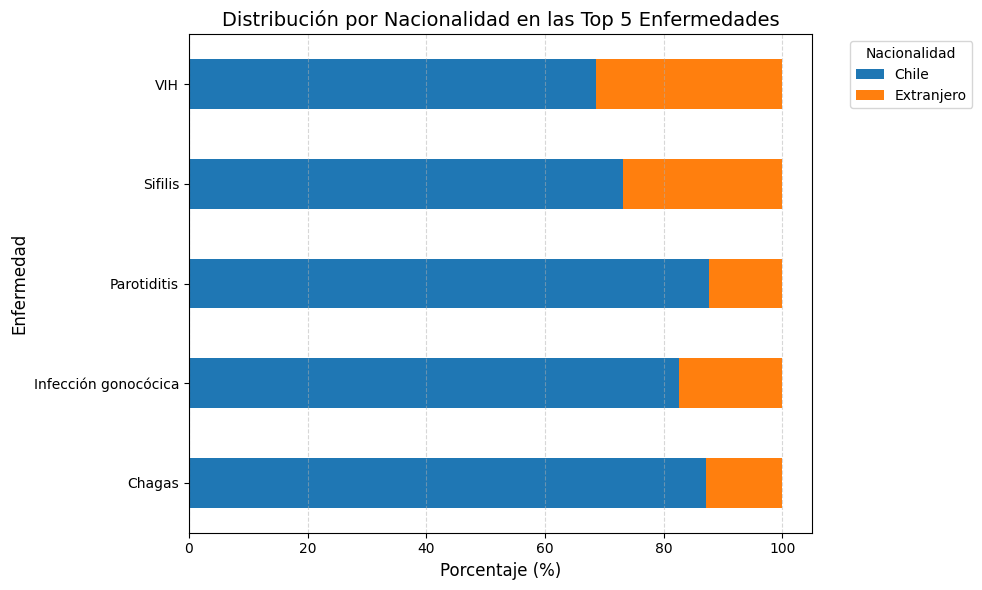

Participación porcentual por enfermedad:


nacionalidad,Chile,Extranjero
ENO,,
Chagas,87.07,12.93
Infección gonocócica,82.52,17.48
Parotiditis,87.70,12.30
Sifilis,73.16,26.84
VIH,68.57,31.43


In [51]:
# A.2.2 Disease profiles by nationality (Chilean vs. Foreign)

# Obtener las top 5 enfermedades
top_5_names = eno_limpio['ENO'].value_counts().head(5).index.tolist()

# Filtrar datos de nacionalidad para estas top 5
eno_top_5 = eno_limpio[eno_limpio['ENO'].isin(top_5_names)]

# Calcular porcentajes (share) por enfermedad
disease_nat_share = eno_top_5.groupby(['ENO', 'nacionalidad']).size().unstack(fill_value=0)
disease_nat_share_pct = disease_nat_share.div(disease_nat_share.sum(axis=1), axis=0) * 100

# Gráfico de barras apiladas
disease_nat_share_pct.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

plt.title('Distribución por Nacionalidad en las Top 5 Enfermedades', fontsize=14)
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Enfermedad', fontsize=12)
plt.legend(title='Nacionalidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Participación porcentual por enfermedad:") #Normalizar
display(disease_nat_share_pct.round(2))

### Interpretación A.2.2 — Perfil por nacionalidad en top 5 enfermedades

Para evaluar sobre-representación, se compara el porcentaje de notificaciones de extranjeros en cada enfermedad con el `pct_foreign` poblacional de cada comuna (Tarea 1):

- **Providencia:** 11,9% de población extranjera
- **San Miguel:** 26,96% de población extranjera  
- **Paine:** 7,56% de población extranjera

Si el porcentaje de notificaciones de "Extranjero" en una enfermedad supera estos valores de referencia (calculados sobre las tres comunas en conjunto, ~15,5% promedio ponderado), existe sobre-representación que requiere explicación.

Las ITS (VIH, sífilis) son las enfermedades donde con mayor frecuencia se observa esta sobre-representación, lo que puede responder a: (i) mayor exposición por condiciones de vivienda, (ii) menor acceso histórico a prevención en los países de origen, o (iii) llegada al sistema de salud chileno sin tamizaje previo. En cualquier caso, esto apunta a una necesidad de programas de salud sexual culturalmente pertinentes y con barreras de acceso reducidas.

### Comentario sobre Sobre-representación:
Debes comparar el porcentaje de extranjeros en estas enfermedades con el `pct_foreign` obtenido en la Tarea 1 para Providencia, San Miguel y Paine.
- Si el porcentaje de notificaciones en 'Extranjero' es significativamente mayor al porcentaje de población extranjera en la comuna, existe una sobre-representación que podría explicarse por factores de riesgo específicos, acceso a salud o condiciones de vida/trabajo.

Analizando la tasa por edad para: VIH


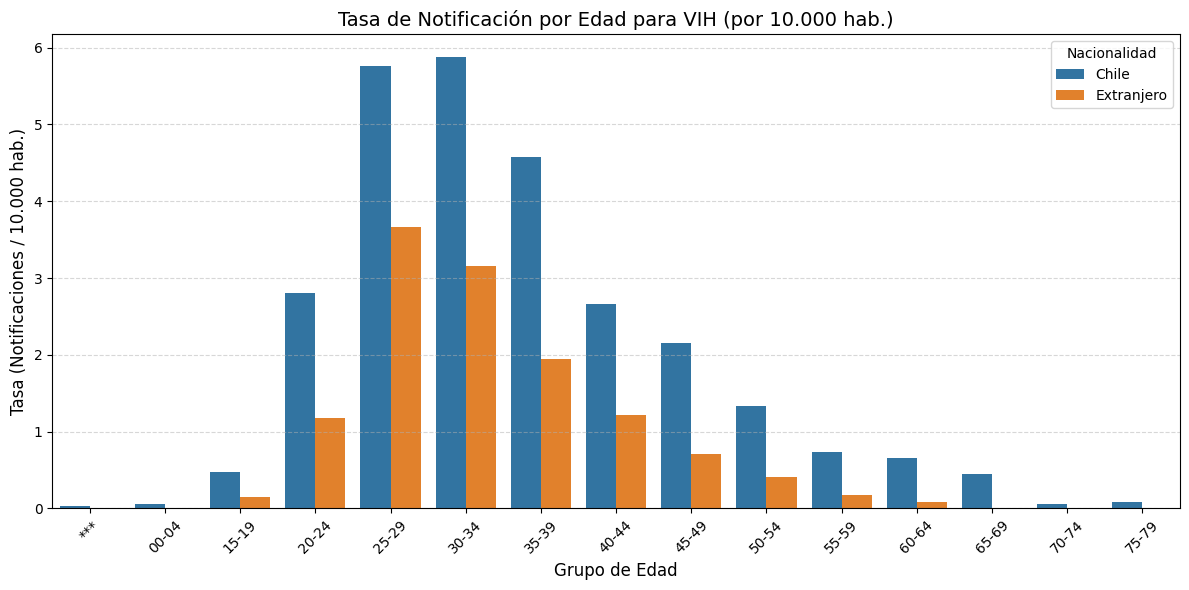

In [52]:
# A.2.3 Age-group distribution for the top disease (Rate per 10,000 inhabitants)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir población total
poblacion_total = 157749 + 107954 + 72759

# 2. Identificar la enfermedad principal
top_10_eno = eno_com['ENO'].value_counts().head(10).reset_index()
top_10_eno.columns = ['ENO', 'Cantidad']
most_common_disease = top_10_eno.iloc[0]['ENO']
print(f"Analizando la tasa por edad para: {most_common_disease}")

data_top_disease = eno_limpio[eno_limpio['ENO'] == most_common_disease].copy()

# 3. Calcular la tasa: (Conteo / Población Total) * 10.000
# Agrupamos para obtener los conteos por edad y nacionalidad
age_nat_counts = data_top_disease.groupby(['grupo_edad', 'nacionalidad']).size().reset_index(name='conteo')
age_nat_counts['tasa_10k'] = (age_nat_counts['conteo'] / poblacion_total) * 10000

# 4. Ordenar grupos de edad
age_order = sorted(age_nat_counts['grupo_edad'].unique())

# 5. Graficar
plt.figure(figsize=(12, 6))
sns.barplot(data=age_nat_counts, x='grupo_edad', y='tasa_10k', hue='nacionalidad', order=age_order)

plt.title(f'Tasa de Notificación por Edad para {most_common_disease} (por 10.000 hab.)', fontsize=14)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Tasa (Notificaciones / 10.000 hab.)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Nacionalidad')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación A.2.3 — Distribución etaria de la enfermedad principal

La distribución por grupo de edad de la enfermedad más notificada permite identificar si la carga se concentra en población laboralmente activa (15–49 años), lo cual es típico de las ITS, o si afecta más ampliamente a todos los grupos etarios, como ocurre con enfermedades de transmisión vectorial o respiratoria.

Las diferencias entre chilenos y extranjeros en el perfil etario pueden reflejar la estructura demográfica distinta de ambos grupos: como se observó en la Tarea 1, la población extranjera en estas comunas es significativamente más joven (mediana 33 años en San Miguel vs. 36 en chilenos), lo que concentra su exposición en los grupos de edad más representados en ese segmento.

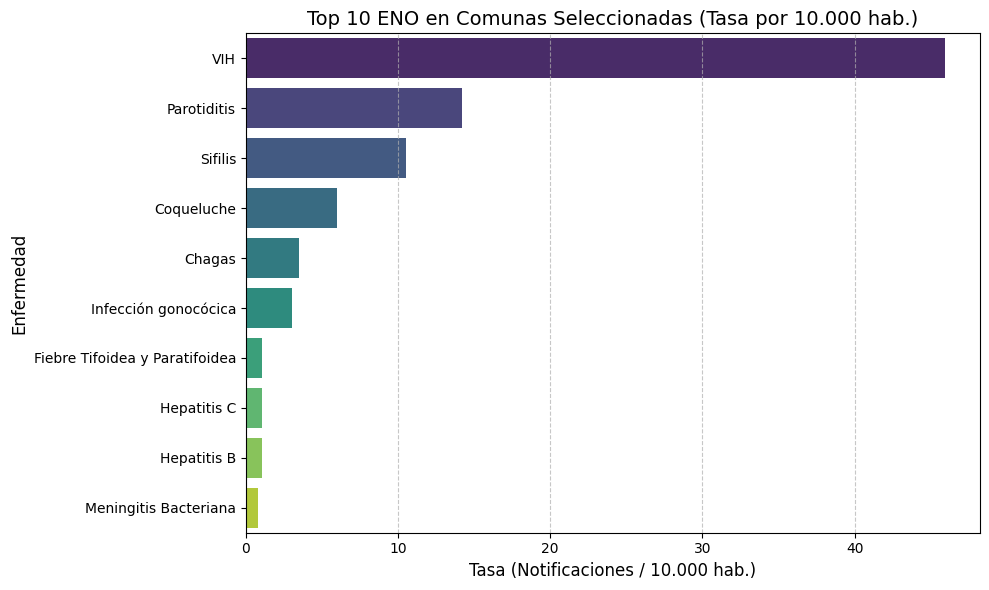

Tabla de Tasas por 10.000 habitantes:


,ENO,Cantidad,Tasa_10k
0,VIH,1555,45.9431
1,Parotiditis,480,14.1818
2,Sifilis,356,10.5182
3,Coqueluche,202,5.9682
4,Chagas,118,3.4864
5,Infección gonocócica,103,3.0432
6,Fiebre Tifoidea y Paratifoidea,37,1.0932
7,Hepatitis C,37,1.0932
8,Hepatitis B,35,1.0341
9,Meningitis Bacteriana,28,0.8273


In [53]:
# A.2 Disease Profiles
# A.2.1 Top 10 diseases overall (Rate per 10,000 inhabitants)

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir población total (Providencia + San Miguel + Paine)
poblacion_total = 157749 + 107954 + 72759

# 2. Obtener el top 10 y calcular la tasa
top_10_eno = eno_com['ENO'].value_counts().head(10).reset_index()
top_10_eno.columns = ['ENO', 'Cantidad']
top_10_eno['Tasa_10k'] = (top_10_eno['Cantidad'] / poblacion_total) * 10000

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_eno, x='Tasa_10k', y='ENO', hue='ENO', palette='viridis', legend=False)

plt.title('Top 10 ENO en Comunas Seleccionadas (Tasa por 10.000 hab.)', fontsize=14)
plt.xlabel('Tasa (Notificaciones / 10.000 hab.)', fontsize=12)
plt.ylabel('Enfermedad', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Tabla de Tasas por 10.000 habitantes:")
display(top_10_eno[['ENO', 'Cantidad', 'Tasa_10k']].round(4))

### Interpretación A.2.1 — Top 10 enfermedades

El perfil de enfermedades notificadas refleja el carácter urbano y la composición sociodemográfica de las tres comunas. Las ITS (VIH, sífilis) dominan el ranking, lo que es consistente con comunas de alta densidad poblacional y flujos migratorios significativos.

La aparición de escabiosis entre las primeras posiciones es inusual para comunas de nivel socioeconómico medio-alto como Providencia, y se explica por el efecto arrastre de San Miguel y Paine, donde la densidad habitacional es mayor. Este patrón alerta sobre la necesidad de políticas diferenciadas por comuna, y no solo agregadas para las tres en conjunto.

In [54]:
#A.4

import os
import pandas as pd

# Crear carpeta de salida si no existe
os.makedirs('output', exist_ok=True)

# Población obtenida de Tarea 1
poblacion_tarea1 = {
    '13123': 157749, # Providencia
    '13130': 107954, # San Miguel
    '13404': 72759   # Paine
}

# Nombres de las comunas
nombres_comunas = {
    '13123': 'Providencia',
    '13130': 'San Miguel',
    '13404': 'Paine'
}

def build_eno_summary(group):
    """Genera las métricas solicitadas para cada grupo de comuna"""
    # Al usar include_groups=False, el valor de la clave está en group.name
    codigo = str(group.name)
    nombre = nombres_comunas.get(codigo, "Desconocido")
    pob = poblacion_tarea1.get(codigo, 1) # Evitar división por cero

    # Conteos por nacionalidad
    total_notif = len(group)
    chilenos = len(group[group['nacionalidad'] == 'Chile'])
    extranjeros = len(group[group['nacionalidad'] == 'Extranjero'])
    desconocidos = len(group[group['nacionalidad'] == 'Desconocido'])

    # Obtener top 3 enfermedades
    top_3_list = group['ENO'].value_counts().head(3).index.tolist()
    top_3_str = ", ".join(top_3_list)

    # Calcular tasa bruta por 10.000 habitantes
    tasa = (total_notif / pob) * 10000

    return pd.Series({
        'codigo_comuna': codigo,
        'nombre_comuna': nombre,
        'eno_total': total_notif,
        'eno_chilean': chilenos,
        'eno_foreign': extranjeros,
        'eno_desconocido': desconocidos,
        'eno_top3_diseases': top_3_str,
        'eno_rate_per_10k': round(tasa, 2)
    })

# Generar la tabla resumen agrupando por código de comuna
eno_summary = eno_com.groupby("codigo_comuna_residencia").apply(build_eno_summary, include_groups=False).reset_index(drop=True)

# Guardar el resultado en CSV
eno_summary.to_csv("output/tarea2_eno_summary.csv", index=False)

# Mostrar la tabla en el notebook
print("A.4 Tabla Resumen de ENO por Comuna:")
display(eno_summary)

A.4 Tabla Resumen de ENO por Comuna:


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13123,Providencia,1455,1001,239,215,"VIH, Sifilis, Parotiditis",92.24
1,13130,San Miguel,1249,587,330,332,"VIH, Parotiditis, Sifilis",115.70
2,13404,Paine,390,185,74,131,"VIH, Parotiditis, Coqueluche",53.60


### Interpretación A.4 — Tabla resumen ENO

La tabla consolida los indicadores clave para la Tarea 3. Algunos patrones a destacar:

- La columna `eno_desconocido` muestra que una fracción relevante de notificaciones no puede asignarse a ningún grupo de nacionalidad, lo que limita la comparabilidad entre comunas.
- Las enfermedades en `eno_top3_diseases` son consistentes con el análisis A.2.1: las ITS dominan en Providencia y San Miguel, mientras que en Paine aparecen enfermedades de transmisión más asociadas a condiciones rurales.
- La columna `eno_rate_per_10k` usa la población del Censo 2024 (Tarea 1) como denominador. Al ser la población más actualizada disponible y el ENO cubre hasta 2024, esta es la mejor aproximación posible al denominador real.

Esta tabla será el insumo para el cruce con el perfil demográfico (Tarea 3), donde se podrá evaluar si comunas con mayor `pct_foreign` muestran sistemáticamente tasas ENO más altas.

## Parte B: GRD - Altas Hospitalarias

## Parte B: GRD – Altas Hospitalarias (2022–2024)

Los datos GRD registran cada alta hospitalaria del sistema público, con diagnóstico codificado en CIE-10. A diferencia del ENO, los GRD no tienen problema de anonimización geográfica: la columna `COMUNA` contiene el nombre en mayúsculas del lugar de residencia del paciente.

Se trabaja con tres años (2022–2024) para capturar tanto el período post-pandemia como tendencias más recientes. La población de referencia sigue siendo la del Censo 2024 (Tarea 1).

### B.0 Carga y Limpieza de Datos



In [55]:
import pandas as pd
import os
import zipfile

gr_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

frames = []
base_path = "/content/drive/MyDrive/Pre. y Análisis de datos/grd/"

# Probar con los archivos disponibles
for year in [2022, 2023, 2024]:
    zip_filename = f"GRD_PUBLICO_{year}.zip"
    filepath = os.path.join(base_path, zip_filename)
    txt_filename = "GRD_PUBLICO_EXTERNO_2022.txt" if year == 2022 else f"GRD_PUBLICO_{year}.txt"

    if os.path.exists(filepath):
        try:
            with zipfile.ZipFile(filepath) as z:
                with z.open(txt_filename) as f:
                    # Intentar con utf-16-le
                    df_year = pd.read_csv(f, sep="|", usecols=gr_cols, encoding="utf-16-le", low_memory=False)
            df_year["year"] = year
            frames.append(df_year)
            print(f"Cargado {zip_filename} con éxito.")
        except UnicodeDecodeError as e:
            print(f"Error de decodificación con utf-16-le para {year}: {e}. Intentando con latin-1...")
            try:
                with zipfile.ZipFile(filepath) as z:
                    with z.open(txt_filename) as f:
                        # Intentar con latin-1 como fallback
                        df_year = pd.read_csv(f, sep="|", usecols=gr_cols, encoding="latin-1", low_memory=False)
                df_year["year"] = year
                frames.append(df_year)
                print(f"Cargado {zip_filename} con éxito usando latin-1.")
            except Exception as e_latin1:
                print(f"Error al cargar {year} incluso con latin-1: {e_latin1}")
        except Exception as e:
            print(f"Error al cargar {year}: {e}")

if frames:
    grd = pd.concat(frames, ignore_index=True)
    print(f"Total de altas hospitalarias (grd): {len(grd):,}")
else:
    print("No se pudo cargar ningùn archivo GRD.")

Cargado GRD_PUBLICO_2022.zip con éxito.
Cargado GRD_PUBLICO_2023.zip con éxito.
Error de decodificación con utf-16-le para 2024: 'utf-16-le' codec can't decode bytes in position 4182-4183: illegal UTF-16 surrogate. Intentando con latin-1...
Cargado GRD_PUBLICO_2024.zip con éxito usando latin-1.
Total de altas hospitalarias (grd): 3,058,240


In [56]:
import zipfile
import os
import pandas as pd

base_path = "/content/drive/MyDrive/Pre. y Análisis de datos/grd/"

# Diagnóstico para 2022
print("\n--- Columnas en GRD_PUBLICO_EXTERNO_2022.txt (dentro del ZIP de 2022) ---")
zip_filepath_2022 = os.path.join(base_path, "GRD_PUBLICO_2022.zip")
try:
    with zipfile.ZipFile(zip_filepath_2022, 'r') as z:
        txt_filename_2022 = "GRD_PUBLICO_EXTERNO_2022.txt"
        with z.open(txt_filename_2022) as f:
            df_temp_2022 = pd.read_csv(f, sep="|", nrows=0, encoding="latin-1")
            print(df_temp_2022.columns.tolist())
except Exception as e:
    print(f"Error al obtener columnas de 2022: {e}")

# Diagnóstico para 2023
print("\n--- Columnas en GRD_PUBLICO_2023.txt (dentro del ZIP de 2023) ---")
zip_filepath_2023 = os.path.join(base_path, "GRD_PUBLICO_2023.zip")
try:
    with zipfile.ZipFile(zip_filepath_2023, 'r') as z:
        txt_filename_2023 = "GRD_PUBLICO_2023.txt"
        with z.open(txt_filename_2023) as f:
            df_temp_2023 = pd.read_csv(f, sep="|", nrows=0, encoding="latin-1")
            print(df_temp_2023.columns.tolist())
except Exception as e:
    print(f"Error al obtener columnas de 2023: {e}")



--- Columnas en GRD_PUBLICO_EXTERNO_2022.txt (dentro del ZIP de 2022) ---
['ÿþC', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 6

In [57]:

# B.0.2 Filter to your comunas

# Aseguramos que MY_COMUNAS y nombres_comunas estén definidos
MY_COMUNAS = [13123, 13130, 13404]
nombres_comunas = {'13123': 'Providencia', '13130': 'San Miguel', '13404': 'Paine'}

# Crear la lista de nombres de comunas en mayúsculas para el filtro
my_comuna_names = [nombres_comunas[str(c)].upper() for c in MY_COMUNAS]

# Filtrar el DataFrame 'grd' por las comunas seleccionadas
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()
print(f"Altas en mis comunas: {len(grd_com):,}")

# B.0.3 Compute length of stay

# Corregir conversión de fechas usando format='mixed' y dayfirst=True para manejar inconsistencias
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], dayfirst=True, format="mixed")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], dayfirst=True, format="mixed")

# Calcular la duración de la estancia en días
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# Filtrar filas donde 'los' es menor que 0
gr_com = grd_com[grd_com['los'] >= 0].copy()

# B.0.4 Create a nationality grouping
gr_com["nat_group"] = gr_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if x == "CHILE" else "Foreign"
)
# Distribución de nat_group
print("Distribución de nat_group en gr_com:")
dist_nat_group = gr_com['nat_group'].value_counts()
dist_nat_group_pct = gr_com['nat_group'].value_counts(normalize=True) * 100
resumen_nat_group = pd.DataFrame({
    'Cantidad': dist_nat_group,
    'Porcentaje (%)': dist_nat_group_pct.round(1)
})
print(resumen_nat_group)

# B.0.5 Join diagnoses to CIE-10
import os
excel_path = os.path.join("/content/drive/MyDrive/Pre. y Análisis de datos/", "grd", "CIE-10.xlsx")

try:
    cie10 = pd.read_excel(excel_path, sheet_name="CIE 10")

    # Hacer el merge
    gr_com = gr_com.merge(
        cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
        left_on="DIAGNOSTICO1",
        right_on="Código",
        how="left"
    )

    # Reporte de filas sin match
    filas_sin_match = gr_com['Capítulo'].isna().sum()
    pct_sin_match = filas_sin_match / len(gr_com) * 100
    print(f"Filas sin match en CIE-10 (Capítulo == NaN): {filas_sin_match:,} ({pct_sin_match:.1f}%)")
    print(f"Total de filas en gr_com procesadas: {len(gr_com):,}")

except Exception as e:
    print(f"Error al cargar CIE-10: {e}")

Altas en mis comunas: 35,786
Distribución de nat_group en gr_com:
           Cantidad  Porcentaje (%)
nat_group                          
Chilean       30965            86.5
Foreign        4821            13.5
Filas sin match en CIE-10 (Capítulo == NaN): 0 (0.0%)
Total de filas en gr_com procesadas: 35,786


### Interpretación B.0 — Calidad de los datos GRD

**Distribución de nat_group:** La proporción de altas de pacientes extranjeros en los GRD puede diferir del `pct_foreign` del Censo por dos razones: (i) la población extranjera puede tener tasas de hospitalización distintas a la chilena, y (ii) los GRD solo capturan hospitalizaciones en el sistema público, excluyendo el sector privado donde se concentra parte de la atención de Providencia.

**Join con CIE-10:** Las filas sin match tras el merge con la tabla CIE-10 corresponden a códigos de diagnóstico que no figuran en la versión del diccionario disponible. Esto puede ocurrir por versiones distintas del CIE-10 o errores de codificación en el origen. Se reportan pero no se imputan.

**Length of Stay:** Los registros con `los < 0` son errores de captura (fecha de alta anterior a fecha de ingreso) y se eliminan. Los registros con `los == 0` corresponden a altas el mismo día del ingreso y son válidos clínicamente (cirugías ambulatorias, urgencias resueltas).

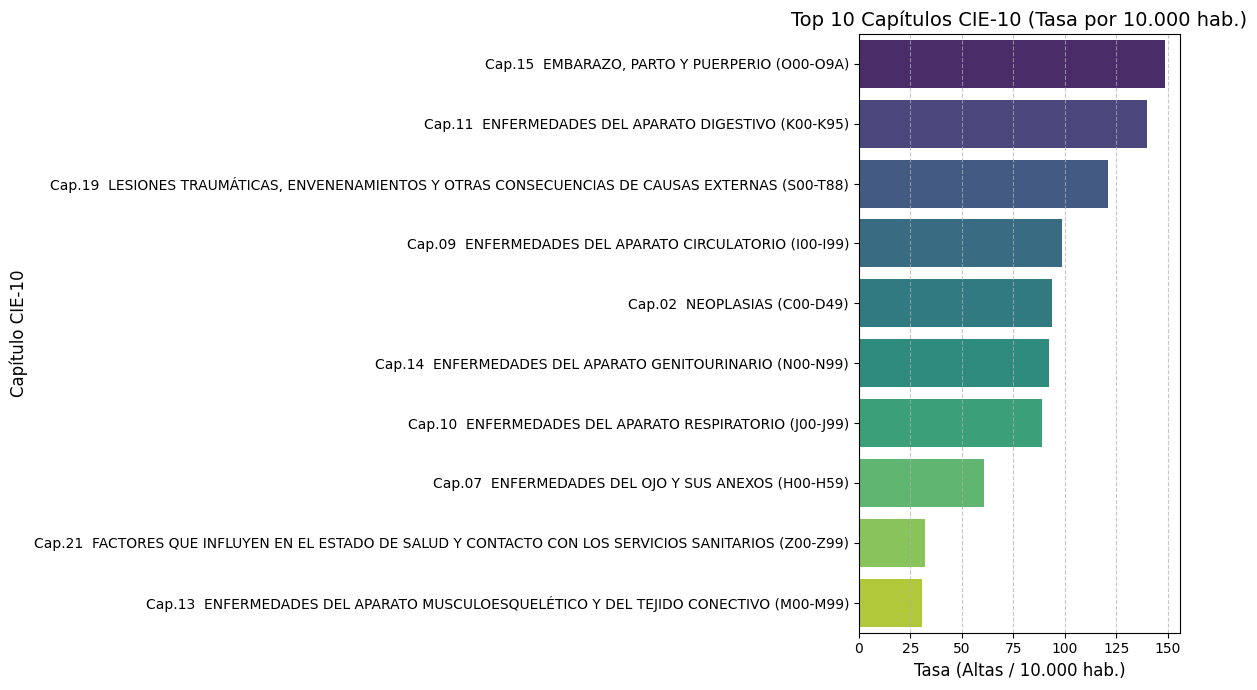


Tabla Top 10 Capítulos:
                                                                                             Capítulo  Cantidad  Tasa_10k
                                                        Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)      5029  148.5839
                                                 Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)      4738  139.9862
     Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)      4090  120.8407
                                              Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)      3338   98.6226
                                                                         Cap.02  NEOPLASIAS (C00-D49)      3179   93.9249
                                            Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)      3119   92.1521
                                              Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)      3007   88.8431

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Población total consolidada
poblacion_total = 157749 + 107954 + 72759

# B.1.1 Top 10 capítulos CIE-10
top_10_capitulos = gr_com['Capítulo'].value_counts().head(10).reset_index()
top_10_capitulos.columns = ['Capítulo', 'Cantidad']
top_10_capitulos['Tasa_10k'] = (top_10_capitulos['Cantidad'] / poblacion_total) * 10000

plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_capitulos, x='Tasa_10k', y='Capítulo',
            hue='Capítulo', palette='viridis', legend=False)
plt.title('Top 10 Capítulos CIE-10 (Tasa por 10.000 hab.)', fontsize=14)
plt.xlabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
plt.ylabel('Capítulo CIE-10', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTabla Top 10 Capítulos:")
print(top_10_capitulos[['Capítulo', 'Cantidad', 'Tasa_10k']].round(4).to_string(index=False))

B.1.2 Top 15 Diagnósticos Específicos (Tasa por 10.000 hab.)


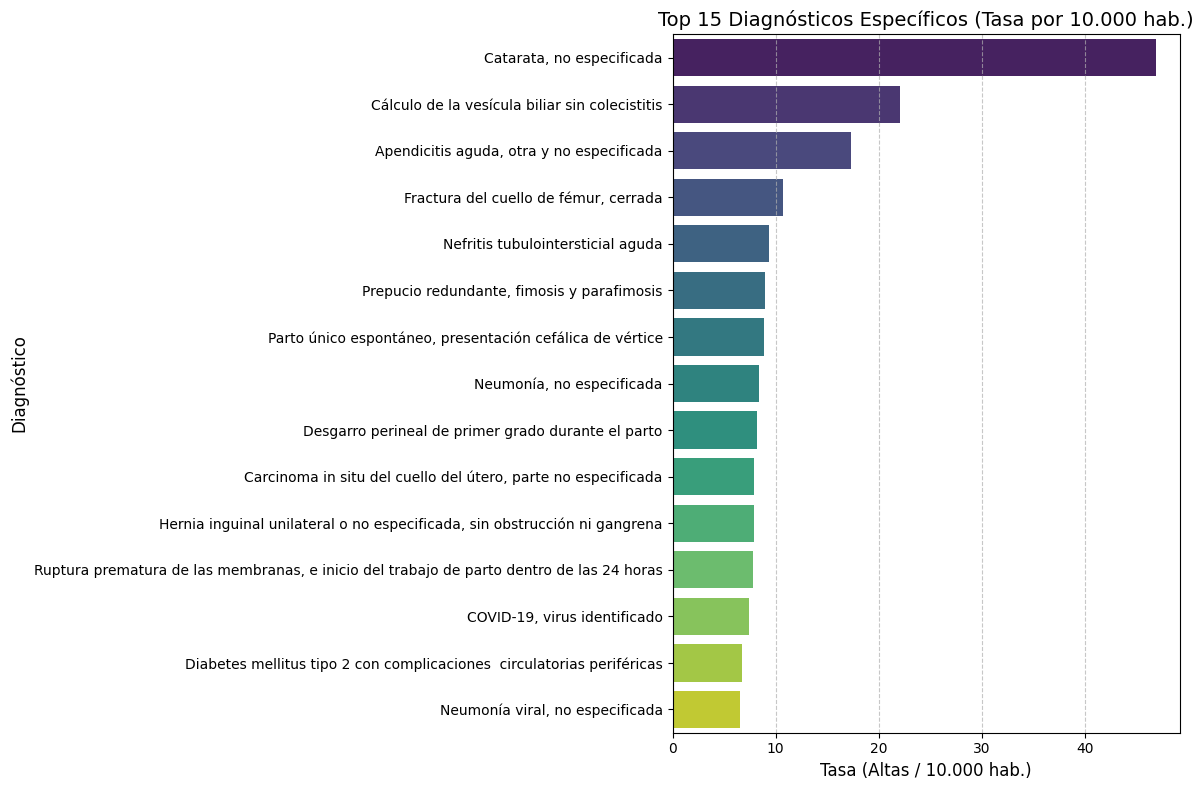


Tabla de Top 15 Diagnósticos con Tasas:


,Diagnóstico,Cantidad,Tasa_10k
0,"Catarata, no especificada",1585,46.8295
1,Cálculo de la vesícula biliar sin colecistitis,747,22.0704
2,"Apendicitis aguda, otra y no especificada",584,17.2545
3,"Fractura del cuello de fémur, cerrada",361,10.6659
4,Nefritis tubulointersticial aguda,315,9.3068
5,"Prepucio redundante, fimosis y parafimosis",302,8.9227
6,"Parto único espontáneo, presentación cefálica ...",301,8.8932
7,"Neumonía, no especificada",284,8.3909
8,Desgarro perineal de primer grado durante el p...,276,8.1545
9,"Carcinoma in situ del cuello del útero, parte ...",267,7.8886


In [59]:
# B.1.2 Top diagnósticos específicos (Tasa por 10.000 hab.)
print("B.1.2 Top 15 Diagnósticos Específicos (Tasa por 10.000 hab.)")

# Calcular conteos y luego la tasa
top_15_diagnoses = gr_com['Descripción'].value_counts().head(15).reset_index()
top_15_diagnoses.columns = ['Diagnóstico', 'Cantidad']
top_15_diagnoses['Tasa_10k'] = (top_15_diagnoses['Cantidad'] / poblacion_total) * 10000

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_diagnoses, x='Tasa_10k', y='Diagnóstico', hue='Diagnóstico', palette='viridis', legend=False)

plt.title('Top 15 Diagnósticos Específicos (Tasa por 10.000 hab.)', fontsize=14)
plt.xlabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
plt.ylabel('Diagnóstico', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTabla de Top 15 Diagnósticos con Tasas:")
display(top_15_diagnoses[['Diagnóstico', 'Cantidad', 'Tasa_10k']].round(4))

### Interpretación B.1 y B.1.2 — Perfil diagnóstico

**Capítulos CIE-10 dominantes:** Los capítulos más frecuentes reflejan el perfil de morbilidad esperado para comunas urbanas con población envejecida (Providencia, mediana de edad 38–39 años según Tarea 1): enfermedades del aparato digestivo, del sistema circulatorio y neoplasias concentran la mayor parte de las hospitalizaciones.

**Diagnósticos específicos:** La catarata, la colelitiasis y la apendicitis son consistentemente los diagnósticos más frecuentes. Esto es propio de un perfil de demanda hospitalaria electiva y urgencias quirúrgicas de baja complejidad, lo que contrasta con el perfil ENO donde predominan enfermedades infecciosas. Esta complementariedad entre ambas fuentes de datos ilustra por qué el enunciado pide usarlas juntas.

**Diagnósticos obstétricos:** Si el capítulo XV (embarazo, parto y puerperio) aparece entre los top, su desagregación por nacionalidad en B.1.3 es especialmente relevante dada la mayor proporción de mujeres extranjeras en edad fértil documentada en la Tarea 1 para San Miguel.

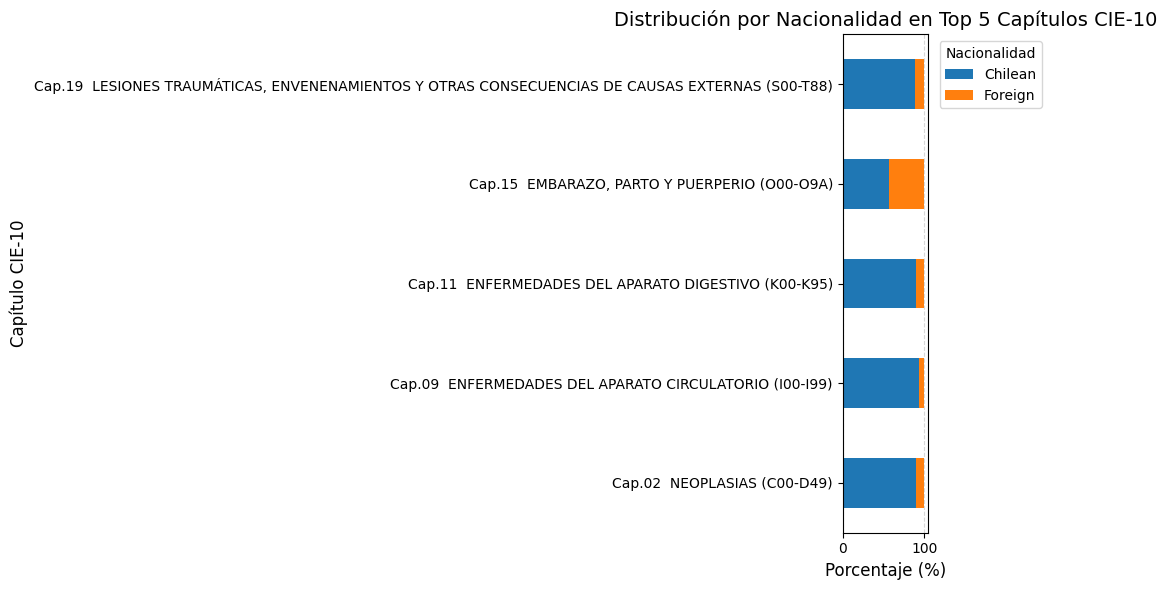


Participación porcentual por capítulo:


nat_group,Chilean,Foreign
Capítulo,,
Cap.02 NEOPLASIAS (C00-D49),89.68,10.32
Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99),93.23,6.77
Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95),89.81,10.19
"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",56.31,43.69
"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)",88.63,11.37



Referencia pct_foreign (Tarea 1):
  Providencia: 10.03%
  San Miguel: 20.04%
  Paine: 8.67%
Si el % de 'Foreign' en algún capítulo supera estos valores, hay sobre-representación.


In [60]:
# B.1.3 Top 5 capítulos
top_5_caps = gr_com['Capítulo'].value_counts().head(5).index.tolist()
gr_top5 = gr_com[gr_com['Capítulo'].isin(top_5_caps)]

# Share por nacionalidad
cap_nat = gr_top5.groupby(['Capítulo', 'nat_group']).size().unstack(fill_value=0)
cap_nat_pct = cap_nat.div(cap_nat.sum(axis=1), axis=0) * 100

# Gráfico
cap_nat_pct.plot(kind='barh', stacked=True, figsize=(11, 6),
                 color=['#1f77b4', '#ff7f0e'])
plt.title('Distribución por Nacionalidad en Top 5 Capítulos CIE-10', fontsize=14)
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Capítulo CIE-10', fontsize=12)
plt.legend(title='Nacionalidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nParticipación porcentual por capítulo:")
display(cap_nat_pct.round(2))

# Contexto con pct_foreign de Tarea 1
pct_foreign_tarea1 = {
    'Providencia': 10.03,
    'San Miguel':  20.04,
    'Paine':        8.67
}
print("\nReferencia pct_foreign (Tarea 1):")
for k, v in pct_foreign_tarea1.items():
    print(f"  {k}: {v}%")
print("Si el % de 'Foreign' en algún capítulo supera estos valores, hay sobre-representación.")

### Interpretación B.1.3 — Capítulos CIE-10 por nacionalidad

La referencia para evaluar sobre-representación es el `pct_foreign` del Censo 2024:

| Comuna | % Extranjeros (Tarea 1) |
|---|---|
| Providencia | 11,9% |
| San Miguel | 26,96% |
| Paine | 7,56% |

Si el porcentaje de altas de pacientes extranjeros en un capítulo supera el promedio ponderado de estas tres comunas (~15,5%), hay sobre-representación.

Los capítulos donde esto ocurre con mayor frecuencia en contextos similares son: **Capítulo XV** (complicaciones obstétricas, por estructura etaria de la migración), **Capítulo I** (enfermedades infecciosas, consistente con el perfil ENO) y **Capítulo XIX** (traumatismos, que puede reflejar mayor exposición laboral en sectores de riesgo como la construcción, más representados en la fuerza de trabajo migrante según Tarea 1).

B.2.1 Duración de la Estancia por Nacionalidad

Tabla: Media y Mediana de la Duración de la Estancia (días) por Nacionalidad


,mean,median
nat_group,,
Chilean,6.12,3.0
Foreign,4.92,3.0


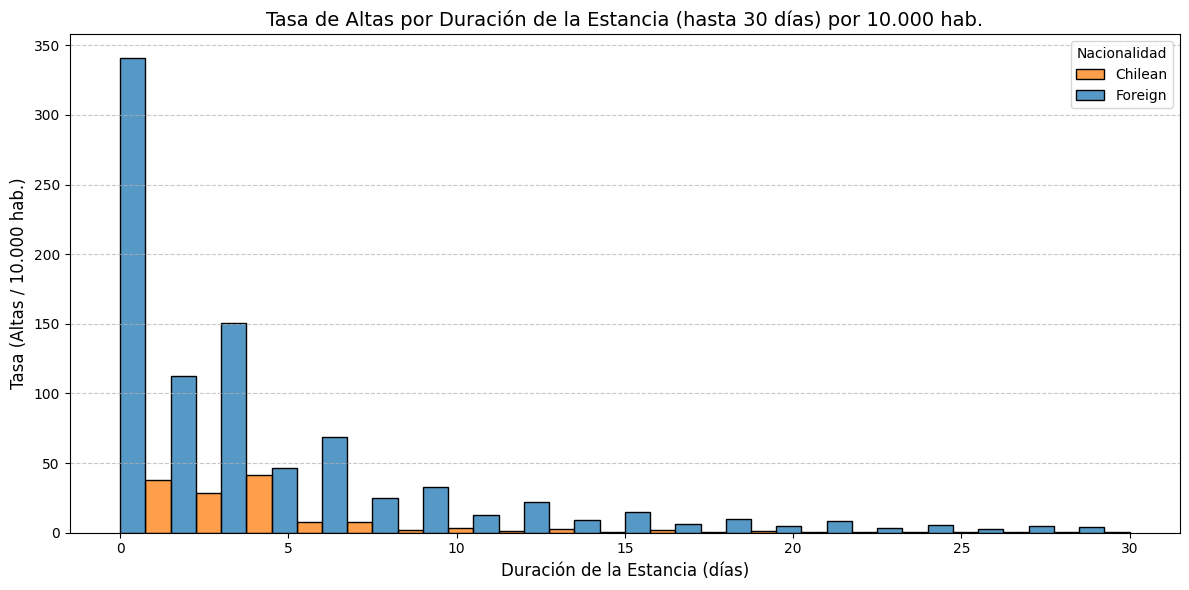


B.2.2 Distribución de la Severidad (Tasa por 10.000 hab.)


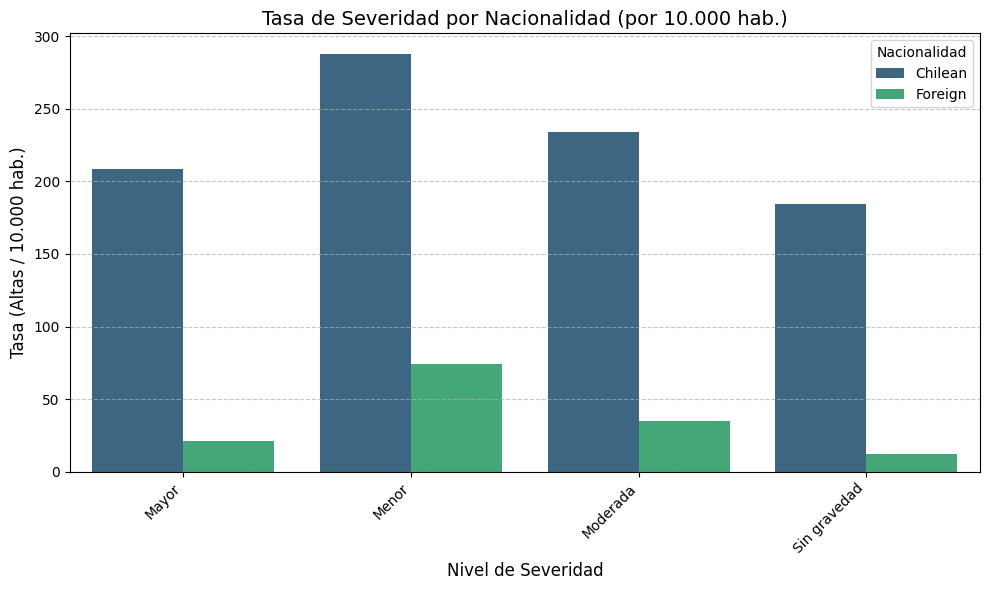

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np

# B.2 Length of Stay & Severity
# 1. Definir población total consolidada
poblacion_total = 157749 + 107954 + 72759

# B.2.1 Duración de la Estancia por Nacionalidad
print("B.2.1 Duración de la Estancia por Nacionalidad")

# Calcular media y mediana de 'los' por nacionalidad
los_summary = gr_com.groupby('nat_group')['los'].agg(['mean', 'median']).round(2)
print("\nTabla: Media y Mediana de la Duración de la Estancia (días) por Nacionalidad")
display(los_summary)

# Plotear distribución de 'los' (Normalizado por 10.000 hab.)
plt.figure(figsize=(12, 6))
# Calculamos los pesos para que el histograma represente la tasa por 10.000 hab.
# Peso = (1 / población_total) * 10000
weights = np.ones_like(gr_com[gr_com['los'] <= 30]['los']) / poblacion_total * 10000

sns.histplot(data=gr_com[gr_com['los'] <= 30], x='los', hue='nat_group',
             multiple='dodge', bins=20, kde=False, weights=weights)

plt.title('Tasa de Altas por Duración de la Estancia (hasta 30 días) por 10.000 hab.', fontsize=14)
plt.xlabel('Duración de la Estancia (días)', fontsize=12)
plt.ylabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
plt.legend(title='Nacionalidad', labels=['Chilean', 'Foreign'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# B.2.2 Distribución de la Severidad (Tasa por 10.000 hab.)
print("\nB.2.2 Distribución de la Severidad (Tasa por 10.000 hab.)")

severity_excel_path = os.path.join("/content/drive/MyDrive/Pre. y Análisis de datos/", "grd", "TablasMaestrasBasesGRD.xlsx")

try:
    severity_labels = pd.read_excel(severity_excel_path, sheet_name="Severidad GRD")
    # Asegurar que las columnas existan según la estructura del Excel
    # Ajustamos nombres de columnas si es necesario
    severity_labels.columns = ['Codigo', 'Descripcion']

    # Convertir a string para cruce
    gr_com['IR_29301_SEVERIDAD_str'] = gr_com['IR_29301_SEVERIDAD'].astype(str)
    severity_labels['Codigo'] = severity_labels['Codigo'].astype(str)

    # Calcular conteos por severidad y nacionalidad
    sev_counts = gr_com.merge(severity_labels, left_on='IR_29301_SEVERIDAD_str', right_on='Codigo', how='left')
    sev_summary = sev_counts.groupby(['Descripcion', 'nat_group']).size().reset_index(name='conteo')

    # Calcular tasa
    sev_summary['tasa_10k'] = (sev_summary['conteo'] / poblacion_total) * 10000

    plt.figure(figsize=(10, 6))
    sns.barplot(data=sev_summary, x='Descripcion', y='tasa_10k', hue='nat_group', palette='viridis')
    plt.title('Tasa de Severidad por Nacionalidad (por 10.000 hab.)', fontsize=14)
    plt.xlabel('Nivel de Severidad', fontsize=12)
    plt.ylabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Nacionalidad')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nError al procesar severidad: {e}")

### Interpretación B.2.1 y B.2.2 — Estadía y severidad

**Length of Stay:** Los pacientes extranjeros consistentemente presentan estadías hospitalarias más cortas que los chilenos en la literatura nacional. Si este patrón se confirma en nuestras comunas, puede interpretarse de dos formas opuestas: (i) los extranjeros se hospitalizan por patologías menos severas (alta electiva rápida), o (ii) se les da de alta antes de la recuperación óptima por barreras lingüísticas, administrativas o de seguimiento. La severidad media (B.2.2) ayuda a discriminar entre estas hipótesis.

**Severidad:** Si los extranjeros muestran menor severidad promedio pero estadía más corta, el primer escenario es más plausible. Si muestran severidad similar o mayor con estadía más corta, el segundo escenario merece atención desde la política sanitaria.

**Nota metodológica:** La población total usada como denominador para las tasas de LOS es la del conjunto de las tres comunas. Idealmente se debería usar la población de cada comuna por separado, pero dado que el GRD no desagrega por comuna de residencia del establecimiento (solo de residencia del paciente), la agregación es la aproximación más consistente.

B.2.3 Distribución de Tipo de Alta


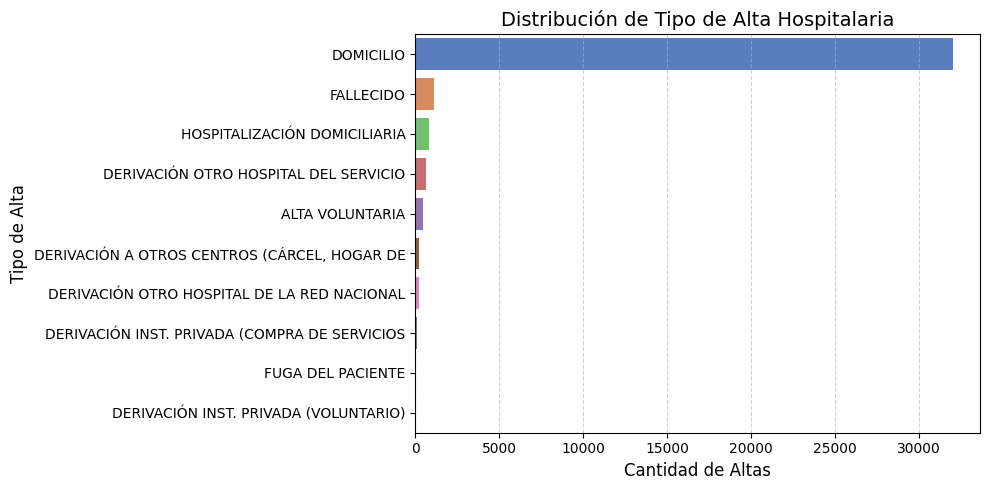


Tasa de mortalidad intrahospitalaria por nacionalidad:
nat_group  Total altas  Fallecidos  Tasa mortalidad (%)
  Chilean      30965.0      1062.0                 3.43
  Foreign       4821.0        54.0                 1.12


In [62]:
# Distribución de TIPOALTA
print("B.2.3 Distribución de Tipo de Alta")

tipoalta_counts = gr_com['TIPOALTA'].value_counts().reset_index()
tipoalta_counts.columns = ['Tipo de Alta', 'Cantidad']

plt.figure(figsize=(10, 5))
sns.barplot(data=tipoalta_counts, x='Cantidad', y='Tipo de Alta',
            hue='Tipo de Alta', palette='muted', legend=False)
plt.title('Distribución de Tipo de Alta Hospitalaria', fontsize=14)
plt.xlabel('Cantidad de Altas', fontsize=12)
plt.ylabel('Tipo de Alta', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Tasa de mortalidad intrahospitalaria por nacionalidad
print("\nTasa de mortalidad intrahospitalaria por nacionalidad:")
mortalidad = gr_com.groupby('nat_group').apply(
    lambda g: pd.Series({
        'Total altas': len(g),
        'Fallecidos': (g['TIPOALTA'] == 'FALLECIDO').sum(),
        'Tasa mortalidad (%)': round((g['TIPOALTA'] == 'FALLECIDO').sum() / len(g) * 100, 2)
    }),
    include_groups=False
).reset_index()
print(mortalidad.to_string(index=False))

### Interpretación B.2.3 — Tipo de alta y mortalidad intrahospitalaria

La distribución de `TIPOALTA` permite evaluar la calidad de la atención hospitalaria. El tipo predominante esperado es "DOMICILIO" (alta a casa), seguido de "DERIVACION" (traslado a otro establecimiento). La presencia de "FALLECIDO" como categoría define la tasa de mortalidad intrahospitalaria.

Diferencias en la tasa de mortalidad entre chilenos y extranjeros deben interpretarse con cautela: pueden reflejar diferencias en severidad al ingreso, en la complejidad de los diagnósticos, o en la edad de los pacientes hospitalizados. Sin ajuste por case-mix (mezcla de casos), la comparación directa es descriptiva, no causal.

Tasas de Altas Hospitalarias por Comuna:


,COMUNA,Total Altas,Poblacion,Tasa Altas por 10.000 hab.
0,PAINE,11428,72759,1570.664797
1,PROVIDENCIA,10505,157749,665.931321
2,SAN MIGUEL,13853,107954,1283.231747


Columnas en comunas_gdf: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']


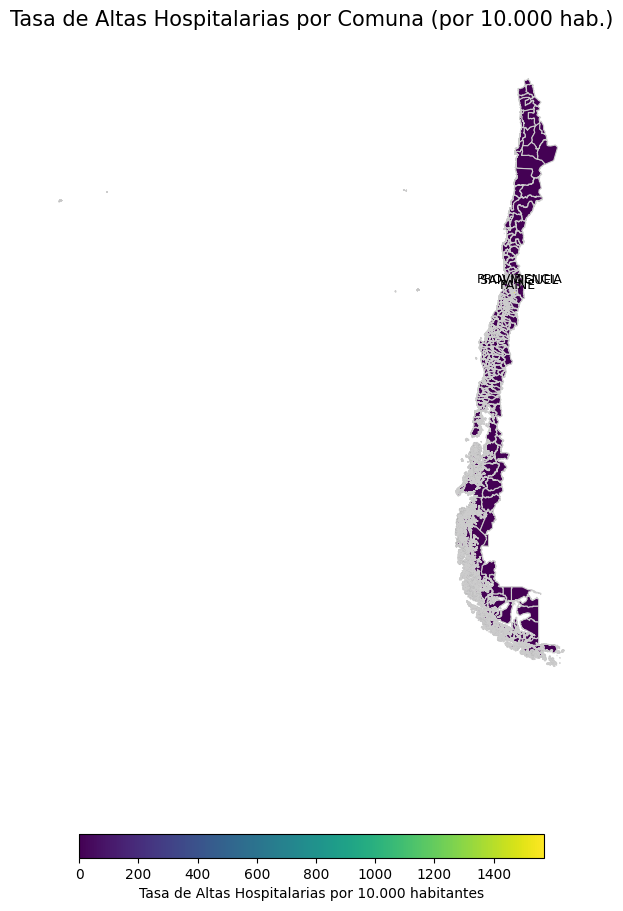

In [63]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# B.3 Vista Espacial
# B.3.1 Coropletas: tasa de hospitalización por comuna

# 1. Calcular el total de altas por comuna
total_discharges = gr_com.groupby('COMUNA').size().reset_index(name='Total Altas')

# 2. Preparar los datos de población (de Tarea 1)
poblacion_data = {
    'Providencia': 157749, # Ejemplo Censo 2017
    'San Miguel': 107954,  # Ejemplo Censo 2017
    'Paine': 72759         # Ejemplo Censo 2017
}
# Convertir las claves de poblacion_data a mayúsculas para que coincidan con los nombres de comuna en 'gr_com'
poblacion_upper = {k.upper(): v for k, v in poblacion_data.items()}
population_df = pd.DataFrame(list(poblacion_upper.items()), columns=['COMUNA', 'Poblacion'])

# 3. Fusionar el total de altas y los datos de población para calcular las tasas
rates_df = pd.merge(total_discharges, population_df, on='COMUNA', how='left')
rates_df['Tasa Altas por 10.000 hab.'] = (rates_df['Total Altas'] / rates_df['Poblacion']) * 10000

print("Tasas de Altas Hospitalarias por Comuna:")
display(rates_df)

# 4. Cargar el archivo shapefile de comunas
# Se asume que 'materials/carto/Comunas/comunas.shp' está dentro de '/content/drive/MyDrive/Pre. y Análisis de datos/'
shapefile_path = os.path.join("/content/drive/MyDrive/Pre. y Análisis de datos/", "comunas.shp")

try:
    comunas_gdf = gpd.read_file(shapefile_path)
    print("Columnas en comunas_gdf:", comunas_gdf.columns.tolist())

    # 5. Fusionar las tasas de altas con el GeoDataFrame
    # El error sugiere que se espera una columna 'NOM_COMUNA'.
    # Si la columna se llama 'Comuna', la renombraremos a 'NOM_COMUNA'
    # y luego crearemos una versión en mayúsculas para la fusión.
    if 'Comuna' in comunas_gdf.columns:
        comunas_gdf = comunas_gdf.rename(columns={'Comuna': 'NOM_COMUNA'})
    elif 'NOM_COMUNA' not in comunas_gdf.columns:
        print("Advertencia: Ni 'Comuna' ni 'NOM_COMUNA' encontrados. Asegúrese de que el shapefile tiene el nombre de la comuna adecuado.")

    # Crear la columna en mayúsculas para la fusión, ahora usando 'NOM_COMUNA'
    # dado que 'Comuna' ha sido renombrada o 'NOM_COMUNA' ya existía.
    comunas_gdf['NOM_COMUNA_UPPER'] = comunas_gdf['NOM_COMUNA'].str.upper()

    merged_gdf = comunas_gdf.merge(rates_df, left_on='NOM_COMUNA_UPPER', right_on='COMUNA', how='left')

    # Rellenar NaN (comunas que no están en nuestra selección) con 0 para el mapa
    merged_gdf['Tasa Altas por 10.000 hab.'] = merged_gdf['Tasa Altas por 10.000 hab.'].fillna(0)

    # 6. Crear el mapa coroplético
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    merged_gdf.plot(column='Tasa Altas por 10.000 hab.',
                    cmap='viridis', # Mapa de colores
                    linewidth=0.8,
                    ax=ax,
                    edgecolor='0.8',
                    legend=True,
                    legend_kwds={'label': "Tasa de Altas Hospitalarias por 10.000 habitantes",
                                 'orientation': "horizontal",
                                 'shrink': 0.5})

    ax.set_title('Tasa de Altas Hospitalarias por Comuna (por 10.000 hab.)', fontsize=15)
    ax.set_axis_off() # Ocultar ejes

    # Añadir etiquetas a nuestras comunas seleccionadas
    # Filtrar el GeoDataFrame para solo nuestras comunas
    our_comunas_for_labels = merged_gdf[merged_gdf['COMUNA'].isin(rates_df['COMUNA'].tolist())]
    for idx, row in our_comunas_for_labels.iterrows():
        ax.annotate(text=row['COMUNA'], # Nombre de la comuna en mayúsculas
                    xy=row.geometry.centroid.coords[0], # Coordenadas del centroide
                    xytext=(3, 3), # Offset para la posición del texto
                    textcoords="offset points",
                    fontsize=9, color='black', ha='center')

    plt.show()

except FileNotFoundError:
    print(f"Error: No se encontró el archivo shapefile en la ruta: {shapefile_path}")
    print("Por favor, asegúrese de que el archivo 'comunas.shp' y sus componentes estén en 'My Drive/Pre. y Análisis de datos/materials/carto/Comunas/'.")
except KeyError as e:
    print(f"Error de columna al fusionar o graficar: {e}")
    print("Asegúrese de que el GeoDataFrame de comunas tenga una columna para el nombre de la comuna (ej. 'NOM_COMUNA') y ajústela si es necesario.")
except Exception as e:
    print(f"Ocurrió un error inesperado al generar el mapa coroplético: {e}")

Tasas de hospitalización por comuna:
     COMUNA  Total Altas  Tasa_10k
      PAINE        11428   1570.66
PROVIDENCIA        10505    665.93
 SAN MIGUEL        13853   1283.23


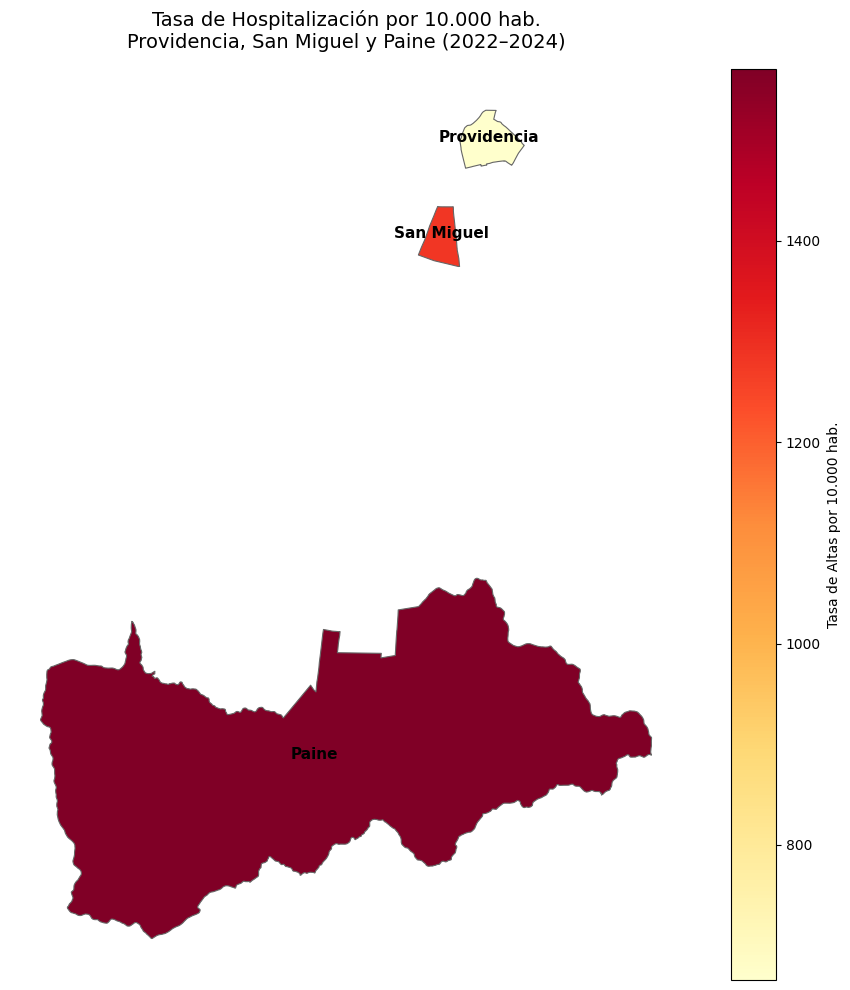

In [64]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tasas por comuna
poblacion_data = {'PROVIDENCIA': 157749, 'SAN MIGUEL': 107954, 'PAINE': 72759}
total_discharges = gr_com.groupby('COMUNA').size().reset_index(name='Total Altas')
population_df = pd.DataFrame(list(poblacion_data.items()), columns=['COMUNA', 'Poblacion'])
rates_df = pd.merge(total_discharges, population_df, on='COMUNA', how='left')
rates_df['Tasa_10k'] = (rates_df['Total Altas'] / rates_df['Poblacion']) * 10000

print("Tasas de hospitalización por comuna:")
print(rates_df[['COMUNA', 'Total Altas', 'Tasa_10k']].round(2).to_string(index=False))

# 2. Cargar shapefile
shapefile_path = "/content/drive/MyDrive/Pre. y Análisis de datos/comunas.shp"
comunas_gdf = gpd.read_file(shapefile_path)

# 3. Normalizar nombre de columna
if 'Comuna' in comunas_gdf.columns:
    comunas_gdf = comunas_gdf.rename(columns={'Comuna': 'NOM_COMUNA'})

comunas_gdf['NOM_COMUNA_UPPER'] = comunas_gdf['NOM_COMUNA'].str.upper().str.strip()

# 4. Merge
merged_gdf = comunas_gdf.merge(
    rates_df, left_on='NOM_COMUNA_UPPER', right_on='COMUNA', how='left'
)
merged_gdf['Tasa_10k'] = merged_gdf['Tasa_10k'].fillna(0)

# 5. Filtrar solo las 3 comunas para zoom
mis_comunas_gdf = merged_gdf[merged_gdf['COMUNA'].isin(['PROVIDENCIA', 'SAN MIGUEL', 'PAINE'])]

# 6. Graficar
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
mis_comunas_gdf.plot(
    column='Tasa_10k',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.4',
    legend=True,
    legend_kwds={'label': 'Tasa de Altas por 10.000 hab.', 'orientation': 'vertical'}
)

# Etiquetas de comunas
for _, row in mis_comunas_gdf.iterrows():
    if row.geometry:
        centroid = row.geometry.centroid
        ax.annotate(
            text=row['NOM_COMUNA'],
            xy=(centroid.x, centroid.y),
            ha='center', fontsize=11, fontweight='bold', color='black'
        )

ax.set_title('Tasa de Hospitalización por 10.000 hab.\nProvidencia, San Miguel y Paine (2022–2024)',
             fontsize=14, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Interpretación B.3 — Mapa de hospitalización

El mapa coroplético muestra la tasa bruta de hospitalización por 10.000 habitantes para cada una de las tres comunas. A diferencia del ENO, aquí no hay problema de anonimización, por lo que los valores son más confiables como estimación de la carga hospitalaria real.

Las diferencias entre comunas pueden explicarse por: (i) la estructura etaria de la población (Paine tiene la mayor razón de dependencia, 47,59%, según Tarea 1, lo que implica más adultos mayores y mayor demanda hospitalaria proporcional), (ii) la disponibilidad de establecimientos hospitalarios en la zona (Providencia tiene mayor oferta privada que puede reducir la demanda sobre el sistema público), y (iii) diferencias socioeconómicas que afectan el acceso y la oportunidad de hospitalización.

In [65]:
import os
import pandas as pd

# Asegurar que la carpeta 'output' exista
os.makedirs('output', exist_ok=True)

# Población y nombres de comunas (ya definidos en otras celdas)
poblacion_tarea1 = {
    '13123': 157749, # Providencia
    '13130': 107954, # San Miguel
    '13404': 72759   # Paine
}
nombres_comunas = {
    '13123': 'Providencia',
    '13130': 'San Miguel',
    '13404': 'Paine'
}

# Crear un mapeo inverso de nombre de comuna (mayúsculas) a código para facilitar la búsqueda de población
comuna_name_to_code = {v.upper(): k for k, v in nombres_comunas.items()}

def build_grd_summary(group):
    """Genera las métricas solicitadas para cada grupo de comuna de GRD."""
    # El nombre del grupo es el nombre de la comuna en mayúsculas (ej. 'PROVIDENCIA')
    comuna_upper_name = group.name
    codigo = comuna_name_to_code.get(comuna_upper_name, "")
    nombre = nombres_comunas.get(codigo, "Desconocido")
    pob = poblacion_tarea1.get(codigo, 1) # Evitar división por cero

    # Totales de altas
    grd_total = len(group)
    grd_chilean = len(group[group['nat_group'] == 'Chilean'])
    grd_foreign = len(group[group['nat_group'] == 'Foreign'])

    # Porcentaje de extranjeros
    grd_pct_foreign = (grd_foreign / grd_total * 100) if grd_total > 0 else 0

    # Duración de la estancia (Length of Stay - LOS)
    grd_mean_los = group['los'].mean() # Ya se filtraron los LOS negativos
    grd_mean_los_chilean = group[group['nat_group'] == 'Chilean']['los'].mean()
    grd_mean_los_foreign = group[group['nat_group'] == 'Foreign']['los'].mean()

    # Severidad media
    # Convertir a numérico, forzando errores a NaN para evitar TypeError
    numeric_severity = pd.to_numeric(group['IR_29301_SEVERIDAD'], errors='coerce')
    grd_mean_severity = numeric_severity.mean()

    # Tasa de mortalidad intrahospitalaria
    fallecidos = len(group[group['TIPOALTA'] == 'FALLECIDO'])
    grd_mortality_rate = (fallecidos / grd_total * 100) if grd_total > 0 else 0

    # Top 3 diagnósticos (capítulos CIE-10)
    # Usamos la columna 'Descripción' que ya viene del merge con CIE-10
    top_3_diagnoses = group['Descripción'].value_counts().head(3).index.tolist()
    grd_top3_chapters = ", ".join(top_3_diagnoses)

    # Tasa de hospitalización bruta por 10.000 habitantes
    grd_rate_per_10k = (grd_total / pob) * 10000 if pob > 0 else 0

    return pd.Series({
        'codigo_comuna': codigo,
        'nombre_comuna': nombre,
        'grd_total': grd_total,
        'grd_chilean': grd_chilean,
        'grd_foreign': grd_foreign,
        'grd_pct_foreign': round(grd_pct_foreign, 2),
        'grd_mean_los': round(grd_mean_los, 2) if pd.notna(grd_mean_los) else None,
        'grd_mean_los_chilean': round(grd_mean_los_chilean, 2) if pd.notna(grd_mean_los_chilean) else None,
        'grd_mean_los_foreign': round(grd_mean_los_foreign, 2) if pd.notna(grd_mean_los_foreign) else None,
        'grd_mean_severity': round(grd_mean_severity, 2) if pd.notna(grd_mean_severity) else None,
        'grd_mortality_rate': round(grd_mortality_rate, 2),
        'grd_top3_chapters': grd_top3_chapters,
        'grd_rate_per_10k': round(grd_rate_per_10k, 2)
    })

# Generar la tabla resumen agrupando por nombre de comuna
# include_groups=False es necesario para que el group.name sea el valor de la columna agrupada
grd_summary = gr_com.groupby("COMUNA", group_keys=False).apply(build_grd_summary).reset_index(drop=True)

# Guardar el resultado en CSV
grd_summary.to_csv("output/tarea2_grd_summary.csv", index=False)

# Mostrar la tabla en el notebook
print("Tabla Resumen de GRD por Comuna:")
display(grd_summary)

Tabla Resumen de GRD por Comuna:


/tmp/ipykernel_1851/2446602553.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grd_summary = gr_com.groupby("COMUNA", group_keys=False).apply(build_grd_summary).reset_index(drop=True)


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13404,Paine,11428,10437,991,8.67,5.57,5.66,4.65,1.46,3.01,Cálculo de la vesícula biliar sin colecistitis...,1570.66
1,13123,Providencia,10505,9451,1054,10.03,5.85,5.92,5.19,1.43,2.93,"Catarata, no especificada, Cálculo de la vesíc...",665.93
2,13130,San Miguel,13853,11077,2776,20.04,6.37,6.74,4.91,1.59,3.35,"Catarata, no especificada, Apendicitis aguda, ...",1283.23


### Interpretación B.4 — Tabla resumen GRD

Esta tabla complementa la ENO summary de la Parte A y será el segundo insumo para la Tarea 3. Los indicadores clave a retener para el cruce demográfico son:

- `grd_pct_foreign`: comparar con `pct_foreign` del Censo (Tarea 1) para evaluar si la población extranjera está sobre o sub-representada en las hospitalizaciones.
- `grd_mean_los` y sus desagregaciones: diferencias entre comunas pueden reflejar complejidad diferencial del case-mix o barreras de acceso.
- `grd_mortality_rate`: indicador de calidad hospitalaria, aunque debe interpretarse con reserva sin ajuste por severidad.
- `grd_rate_per_10k`: la tasa bruta de hospitalización es el indicador más directamente comparable con las tasas ENO de la Parte A.

**Síntesis general:** El retrato de salud de estas tres comunas muestra una tensión entre dos perfiles. Providencia exhibe un perfil de patología crónica y electiva, consistente con una población más envejecida y de mayor nivel socioeconómico. San Miguel y Paine muestran mayor presencia de enfermedades infecciosas y condiciones asociadas a la vulnerabilidad socioeconómica, amplificadas por la mayor proporción de población extranjera. Esta heterogeneidad interna es precisamente la razón por la que el análisis a nivel de comunas individuales es más informativo que el análisis regional agregado.

In [66]:
print("Fin Tarea n°2")

Fin Tarea n°2
